In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys

# project2ディレクトリを直接指定
sys.path.insert(0, r"C:\Users\manat\project2")
import os
import sourse_new
import matplotlib.patches as patches

plt.rcParams["font.size"] = 13


sim_ref = -np.loadtxt(r"C:\Users\manat\project2\data_all\cupy_pitch125_depth0.csv")
exp_ref = sourse_new.import_data(0, 0)[0]

sim_rough = -np.loadtxt(r"C:\Users\manat\project2\data_all\cupy_pitch125_depth20.csv")
exp_rough = sourse_new.import_data(125, 20)[0]

sim_ref = sourse_new.kiritori2(sourse_new.interpolate_sim_one(sim_ref[9000:]), sourse_new.left, sourse_new.right)
exp_ref = sourse_new.kiritori2(exp_ref, sourse_new.left, sourse_new.right)

sim_rough = sourse_new.kiritori2(sourse_new.interpolate_sim_one(sim_rough[9000:]), sourse_new.left, sourse_new.right)
exp_rough = sourse_new.kiritori2(exp_rough, sourse_new.left, sourse_new.right)

yf_sim_ref, freq = sourse_new.make_fftdata(sim_ref, sourse_new.exp_dt)
yf_exp_ref, freq = sourse_new.make_fftdata(exp_ref, sourse_new.exp_dt)

yf_sim_rough, freq = sourse_new.make_fftdata(sim_rough, sourse_new.exp_dt)
yf_exp_rough, freq = sourse_new.make_fftdata(exp_rough, sourse_new.exp_dt)

importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_0.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_1.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_2.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_3.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_4.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_5.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_6.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_7.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_8.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_9.csv
importing : C:\Users\manat\project2\experience_new\125_20\scope_5b1_50.csv
importing : C:\Users\manat\project2\experience_new\125_20\scope_5b1_51.csv
importing : C:\Users\manat\project2\experience_new\125_20\scope_5b1_52.csv
importing : C:\Users\manat\project2\experience_new\125_20\scope_5

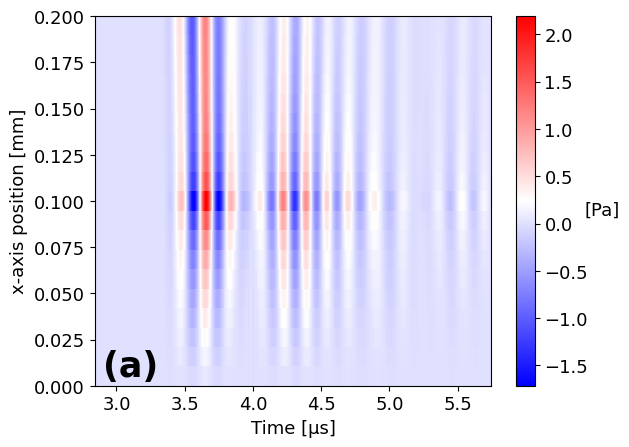

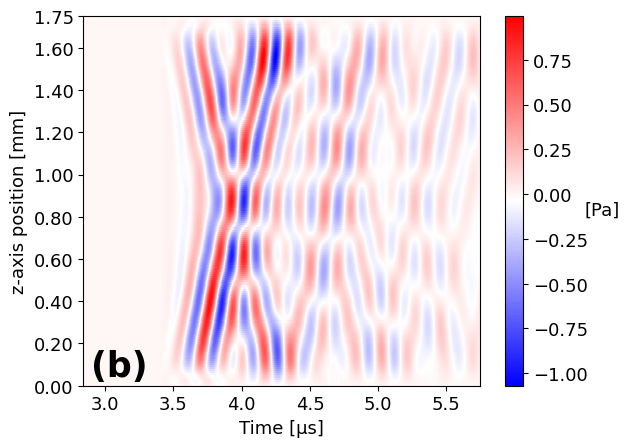

In [ ]:
filename = f"C:\\Users\\manat\\project2\\surface_wave_2d\\T1\\T1_series_middle_moremorerange_200_moredepth_tyoizurasi1975.npy"
filename2 = f"C:\\Users\\manat\\project2\\surface_wave_2d\\T3\\T3_series_middle_moremorerange_200_moredepth_tyoizurasi1975.npy"
data_kabe_T1 = np.load(filename)
data_yuka_T3 = np.load(filename2)

z1 = 49
z2 = 224
x1 = 30
x2 = 40
dt_ns = 0.71  # ns per timestep
time_range = sourse_new.right + sourse_new.left
# プローブ発射を0とした実時間軸
start_time_step = 4000  # 描画開始時のタイムステップ
time_axis_us = [(start_time_step + i) * dt_ns / 1000 for i in range(time_range)]

fig = plt.figure()
im = plt.imshow(
    -data_kabe_T1[x1 - 10 : x2, z1, 1214 - sourse_new.left : 1214 + sourse_new.right],
    extent=(time_axis_us[0], time_axis_us[-1], 0, 0.20),
    interpolation="nearest",
    cmap="bwr",
    aspect="auto",
)
plt.xlabel("Time [μs]")
plt.ylabel(r"x-axis position [mm]")

# 現在の目盛りを取得して、最大値を追加
ax = plt.gca()
current_yticks = list(ax.get_yticks())
if 0.10 not in current_yticks:
    current_yticks.append(0.10)
    ax.set_yticks(sorted(current_yticks))


plt.text(0.02, 0.1, "(a)", transform=plt.gca().transAxes, fontsize=25, weight="bold", ha="left", va="top")
cbar = plt.colorbar(im)
cbar.set_label("[Pa]", rotation=0, labelpad=10)
plt.savefig(r"C:\Users\manat\project2\drawing\jasa\Figure1000a.png", format="eps", dpi=300)
plt.show()

plt.rcParams["font.size"] = 13
fig = plt.figure()
im = plt.imshow(
    -data_yuka_T3[x2 - 2, z1:z2, 1214 - sourse_new.left : 1214 + sourse_new.right],
    extent=(time_axis_us[0], time_axis_us[-1], 0, 1.75),
    interpolation="nearest",
    cmap="bwr",
    aspect="auto",
)
plt.xlabel("Time [μs]")
plt.ylabel(r"z-axis position [mm]")

# 2つ目のプロットでも同様に
ax = plt.gca()
current_yticks = list(ax.get_yticks())
if 1.75 not in current_yticks:
    current_yticks = [tick for tick in current_yticks if abs(tick - 1.75) > 0.01]
    current_yticks.append(1.75)
    ax.set_yticks(sorted(current_yticks))

ax.set_ylim(0, 1.75)  # y軸の範囲を強制的に0-1.75に固定
plt.text(0.02, 0.1, "(b)", transform=plt.gca().transAxes, fontsize=25, weight="bold", ha="left", va="top")
cbar = plt.colorbar(im)
cbar.set_label("[Pa]", rotation=0, labelpad=10)
plt.savefig(r"C:\Users\manat\project2\drawing\jasa\Figure1000b.png", format="png", dpi=300)
plt.show()

In [ ]:
filename = f"C:\\Users\\manat\\project2\\surface_wave_2d\\T1\\T1_series_middle_moremorerange_200_moredepth_tyoizurasi2175.npy"
filename2 = f"C:\\Users\\manat\\project2\\surface_wave_2d\\T3\\T3_series_middle_moremorerange_200_moredepth_tyoizurasi2175.npy"
data_kabe_T1 = np.load(filename)
data_yuka_T3 = np.load(filename2)

z1 = 49
z2 = 224
x1 = 30
x2 = 40
dt_ns = 0.71  # ns per timestep
time_range = sourse_new.right + sourse_new.left
# プローブ発射を0とした実時間軸
start_time_step = 4000  # 描画開始時のタイムステップ
time_axis_us = [(start_time_step + i) * dt_ns / 1000 for i in range(time_range)]

fig = plt.figure()
im = plt.imshow(
    -data_kabe_T1[x1 - 10 : x2, z1, 1214 - sourse_new.left : 1214 + sourse_new.right],
    extent=(time_axis_us[0], time_axis_us[-1], 0, 0.20),
    interpolation="nearest",
    cmap="bwr",
    aspect="auto",
)
plt.xlabel("Time [μs]")
plt.ylabel(r"x-axis position [mm]")

# 現在の目盛りを取得して、最大値を追加
ax = plt.gca()
current_yticks = list(ax.get_yticks())
if 0.10 not in current_yticks:
    current_yticks.append(0.10)
    ax.set_yticks(sorted(current_yticks))


plt.text(0.02, 0.1, "(a)", transform=plt.gca().transAxes, fontsize=25, weight="bold", ha="left", va="top")
cbar = plt.colorbar(im)
cbar.set_label("[Pa]", rotation=0, labelpad=10)
plt.savefig(r"C:\Users\manat\project2\drawing\jasa\Figure1000a.png", format="eps", dpi=300)
plt.show()

plt.rcParams["font.size"] = 13
fig = plt.figure()
im = plt.imshow(
    -data_yuka_T3[x2 - 2, :, 1214 - sourse_new.left : 1214 + sourse_new.right],
    interpolation="nearest",
    cmap="bwr",
    aspect="auto",
)
plt.xlabel("Time [μs]")
plt.ylabel(r"z-axis position [mm]")

# # 2つ目のプロットでも同様に
# ax = plt.gca()
# current_yticks = list(ax.get_yticks())
# if 1.75 not in current_yticks:
#     current_yticks = [tick for tick in current_yticks if abs(tick - 1.75) > 0.01]
#     current_yticks.append(1.75)
#     ax.set_yticks(sorted(current_yticks))

# ax.set_ylim(0, 1.75)  # y軸の範囲を強制的に0-1.75に固定
plt.text(0.02, 0.1, "(b)", transform=plt.gca().transAxes, fontsize=25, weight="bold", ha="left", va="top")
cbar = plt.colorbar(im)
cbar.set_label("[Pa]", rotation=0, labelpad=10)
plt.savefig(r"C:\Users\manat\project2\drawing\jasa\Figure1000b.png", format="png", dpi=300)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\manat\\project2\\surface_wave_2d\\T1\\T1_series_middle_moremorerange_200_moredepth_tyoizurasi2175.npy'